### Import Libraries

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

os.makedirs("charts", exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Load Cleaned Files

In [51]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All cleaned datasets loaded successfully!")

All cleaned datasets loaded successfully!


### Dataset Overview

In [52]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Investor": investor,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("Shape:", df.shape)
    print(df.head())


NAV
Shape: (46000, 3)
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

AUM
Shape: (90, 5)
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

SIP
Shape: (48, 6)
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                   

### Missing Values Check

In [53]:
for name, df in datasets.items():
    print("\n" + name)
    print(df.isnull().sum())


NAV
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category
month               0
category            0
net_inflow_crore    0
dtype: int64

Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

Investor
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

Holdings
amfi_

### AUM Growth By AMC

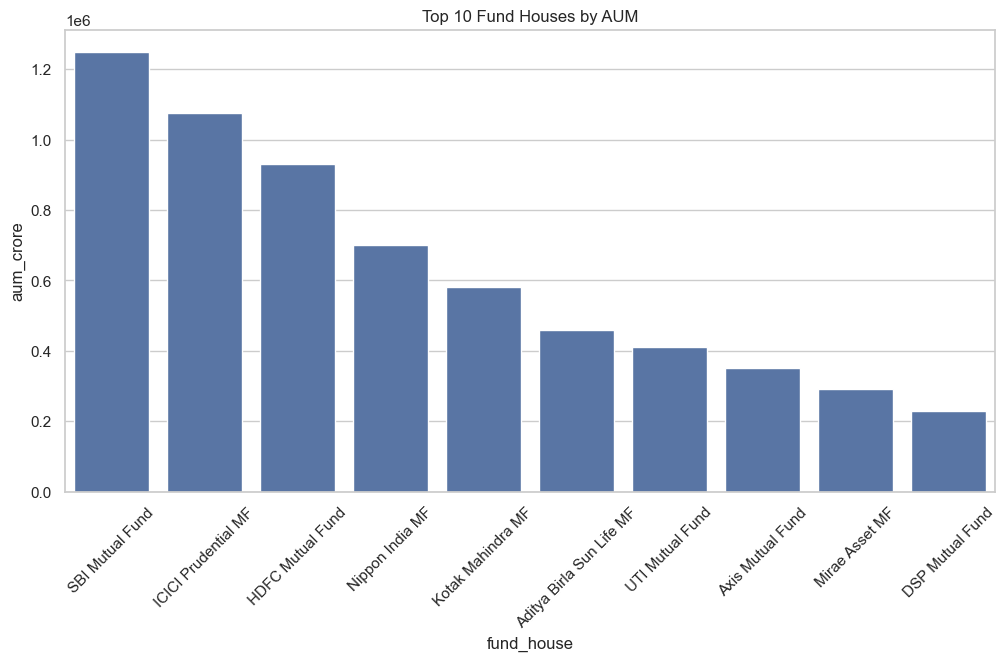

In [54]:
latest_aum = aum.sort_values('date').groupby('fund_house').last()

top10 = latest_aum.sort_values(
    'aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_house',
    y='aum_crore'
)

plt.xticks(rotation=45)

plt.title("Top 10 Fund Houses by AUM")

plt.savefig("../charts/aum_growth.png")
plt.show()

### Monthly SIP Trend

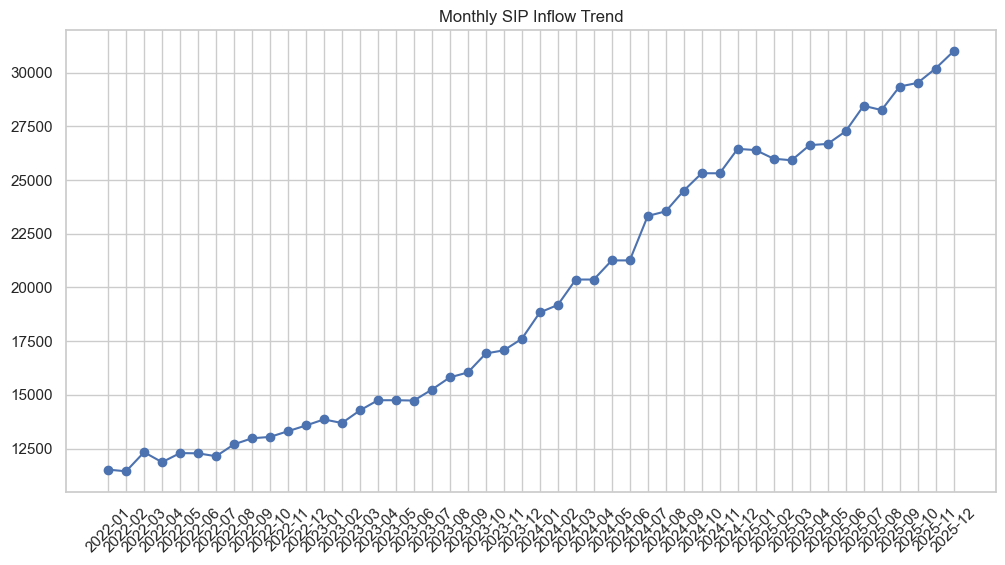

In [55]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly SIP Inflow Trend")

plt.savefig("../charts/sip_trend.png")
plt.show()

### Category Heatmap

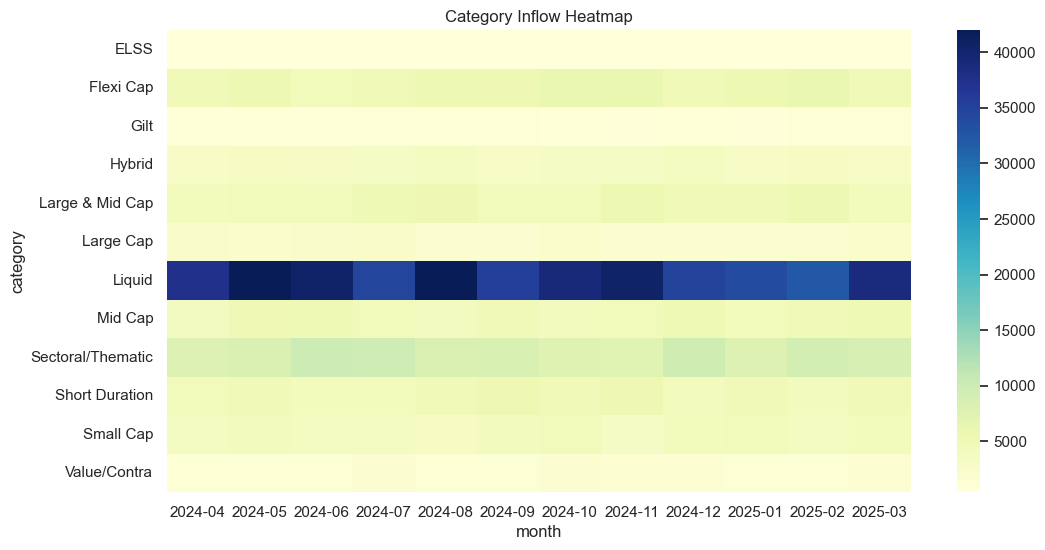

In [56]:
pivot = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")
plt.show()

### Age Group Pie Chart

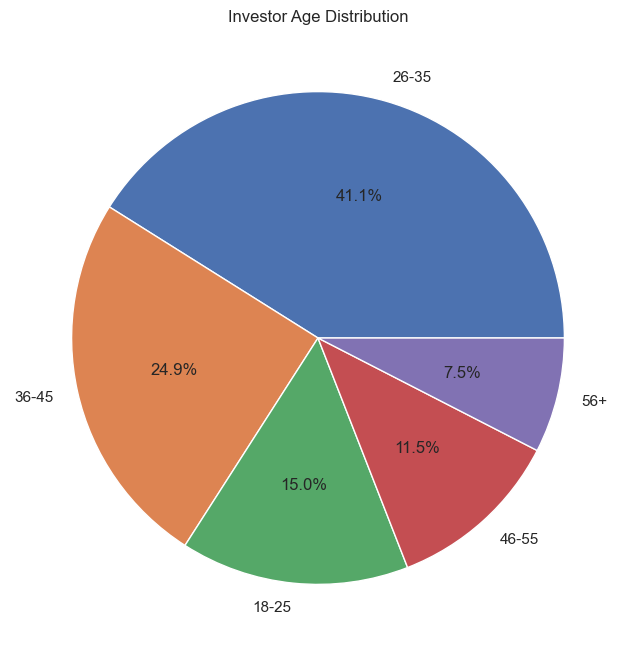

In [57]:
age = investor['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age.values,
    labels=age.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Distribution")

plt.savefig("../charts/age_distribution.png")
plt.show()

### SIP Amount Boxplot by Age

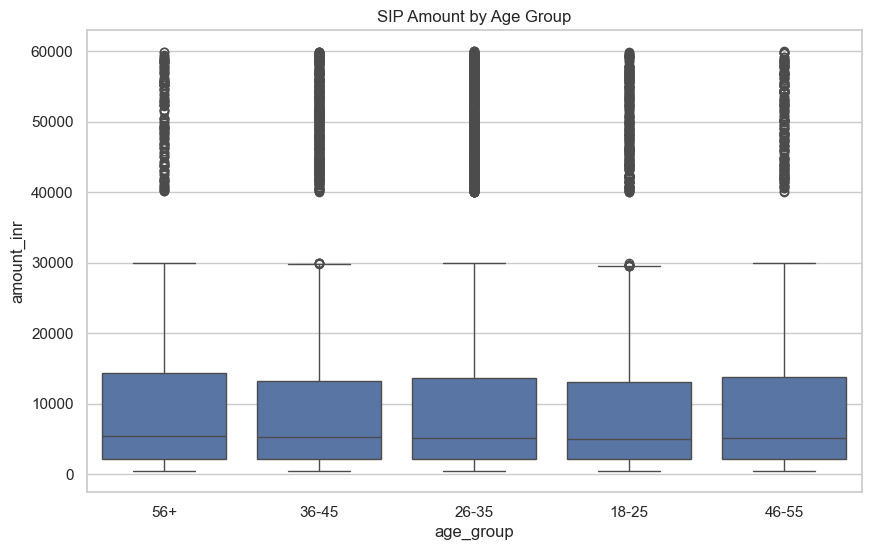

In [58]:
sip_age = investor[
    investor['transaction_type']=="SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_age,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount by Age Group")

plt.savefig("../charts/sip_boxplot.png")
plt.show()

### State-wise Transaction Value

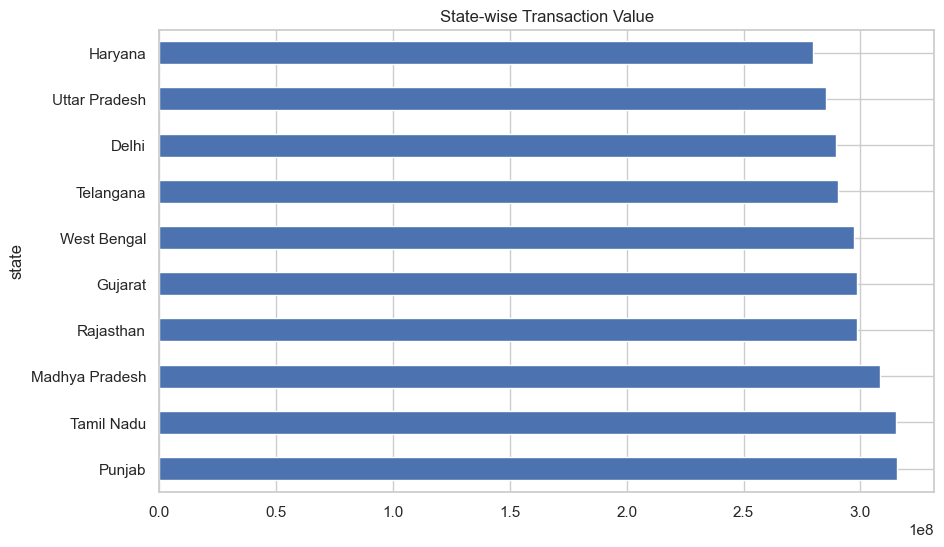

In [59]:
state = investor.groupby(
    'state'
)['amount_inr'].sum()

state = state.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

state.plot(kind='barh')

plt.title("State-wise Transaction Value")

plt.savefig("../charts/state_transactions.png")
plt.show()

### T30 VS B30

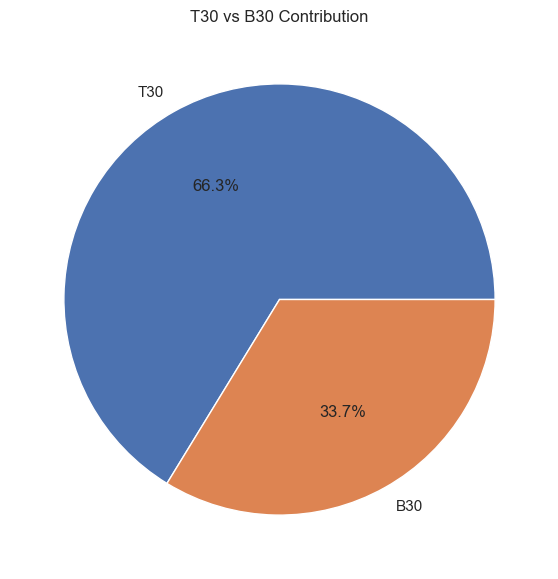

In [60]:
tier = investor['city_tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier.values,
    labels=tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Contribution")

plt.savefig("../charts/t30_b30.png")
plt.show()

### Folio Growth

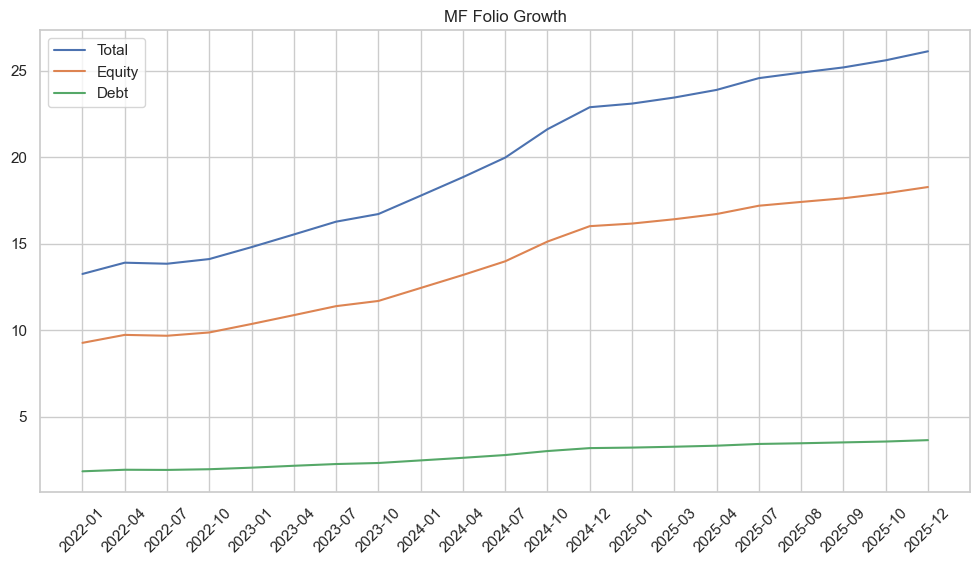

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    label='Total'
)

plt.plot(
    folio['month'],
    folio['equity_folios_crore'],
    label='Equity'
)

plt.plot(
    folio['month'],
    folio['debt_folios_crore'],
    label='Debt'
)

plt.legend()

plt.xticks(rotation=45)

plt.title("MF Folio Growth")

plt.savefig("../charts/folio_growth.png")
plt.show()

### Correlation Matrix

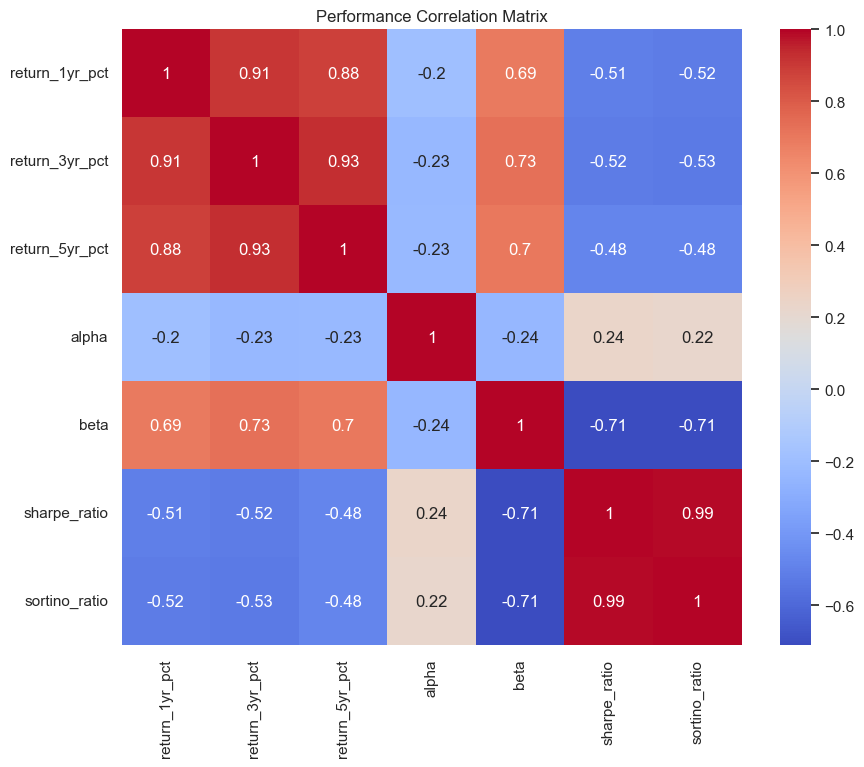

In [62]:
corr = performance[
    [
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'alpha',
        'beta',
        'sharpe_ratio',
        'sortino_ratio'
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Performance Correlation Matrix")

plt.savefig("../charts/correlation_matrix.png")
plt.show()

### Sector Allocation Donut

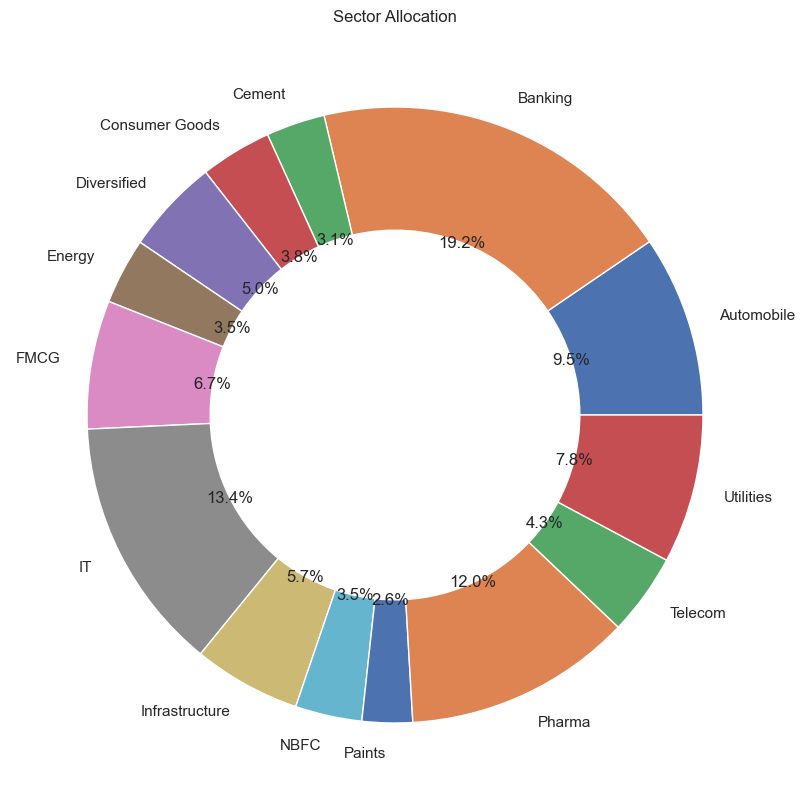

In [63]:
sector = holdings.groupby(
    'sector'
)['weight_pct'].sum()

plt.figure(figsize=(10,10))

plt.pie(
    sector.values,
    labels=sector.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation")

plt.savefig("../charts/sector_allocation.png")
plt.show()

### Top Stocks by Weight

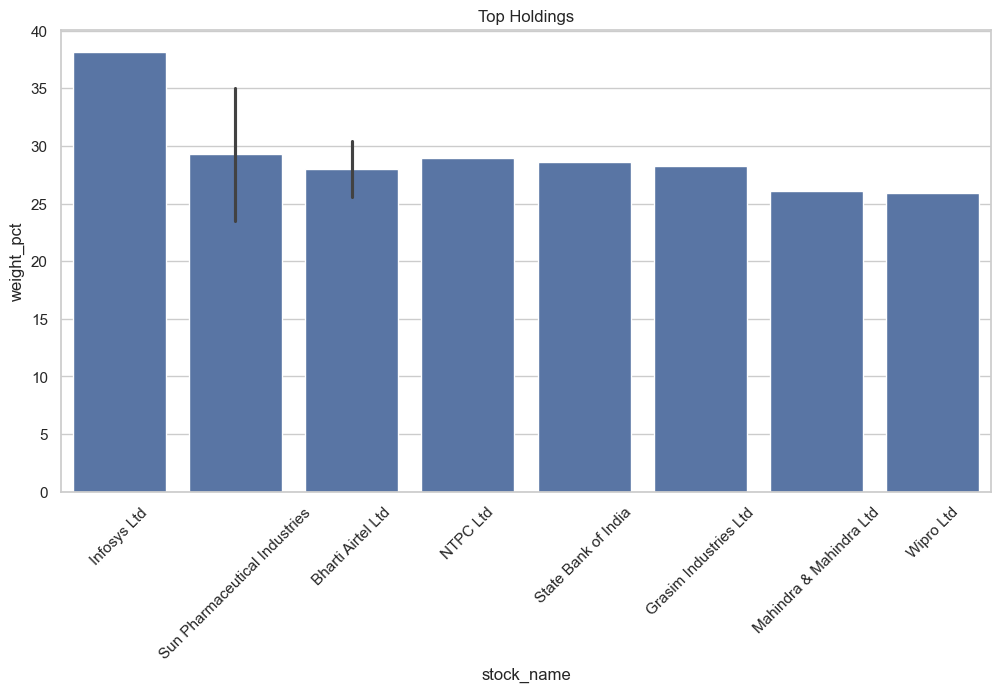

In [64]:
top = holdings.sort_values(
    'weight_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x='stock_name',
    y='weight_pct'
)

plt.xticks(rotation=45)

plt.title("Top Holdings")

plt.savefig("../charts/top_holdings.png")
plt.show()

### Sector Market Value

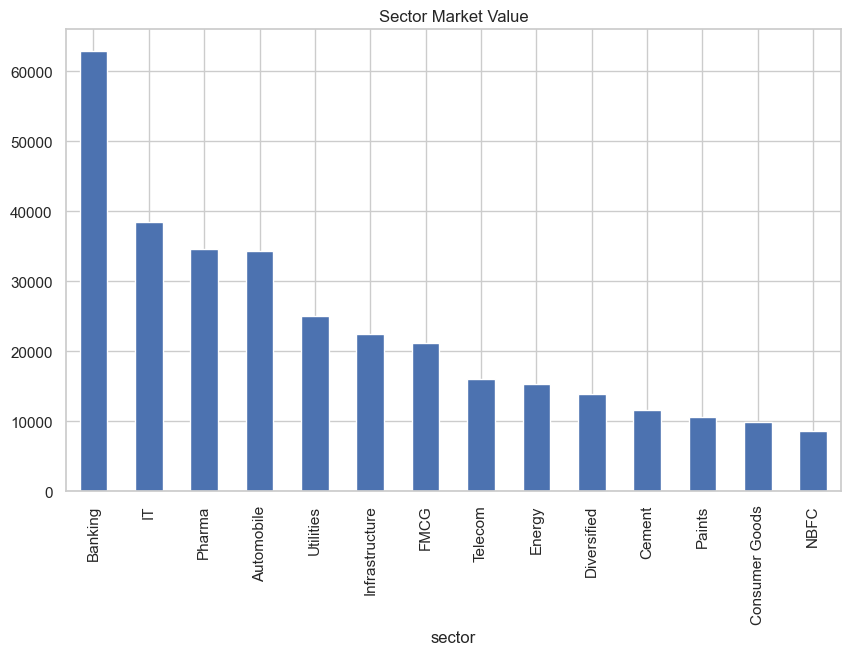

In [65]:
mv = holdings.groupby(
    'sector'
)['market_value_cr'].sum()

mv = mv.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

mv.plot(kind='bar')

plt.title("Sector Market Value")

plt.savefig("../charts/sector_market_value.png")
plt.show()

### Stock Price Distribution

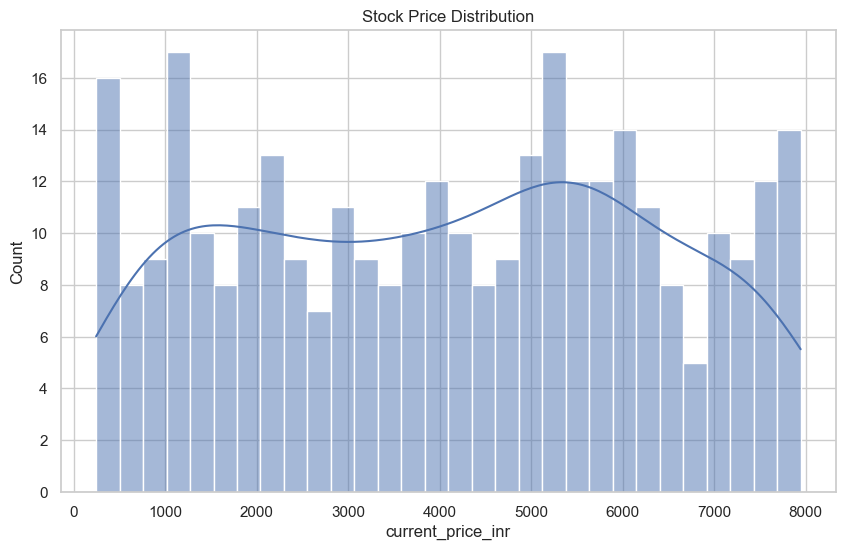

In [66]:
plt.figure(figsize=(10,6))

sns.histplot(
    holdings['current_price_inr'],
    bins=30,
    kde=True
)

plt.title("Stock Price Distribution")

plt.savefig("../charts/stock_price_dist.png")
plt.show()

### Risk vs Return Bubble Plot

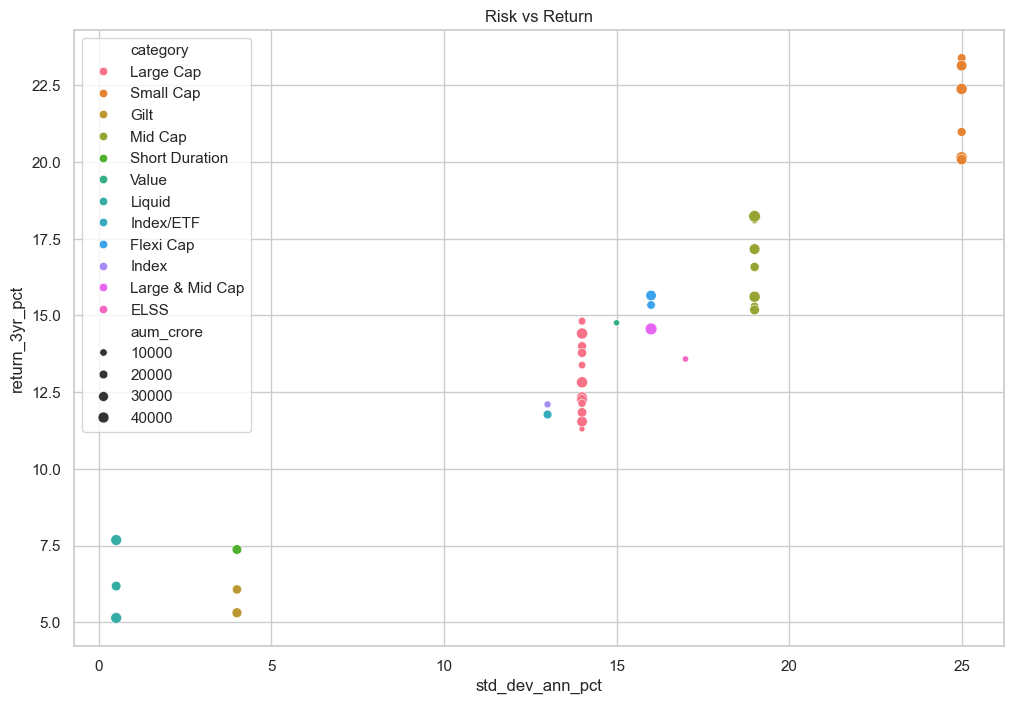

In [67]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    size='aum_crore',
    hue='category'
)

plt.title("Risk vs Return")

plt.savefig("../charts/risk_return.png")
plt.show()

### Benchmark Trend

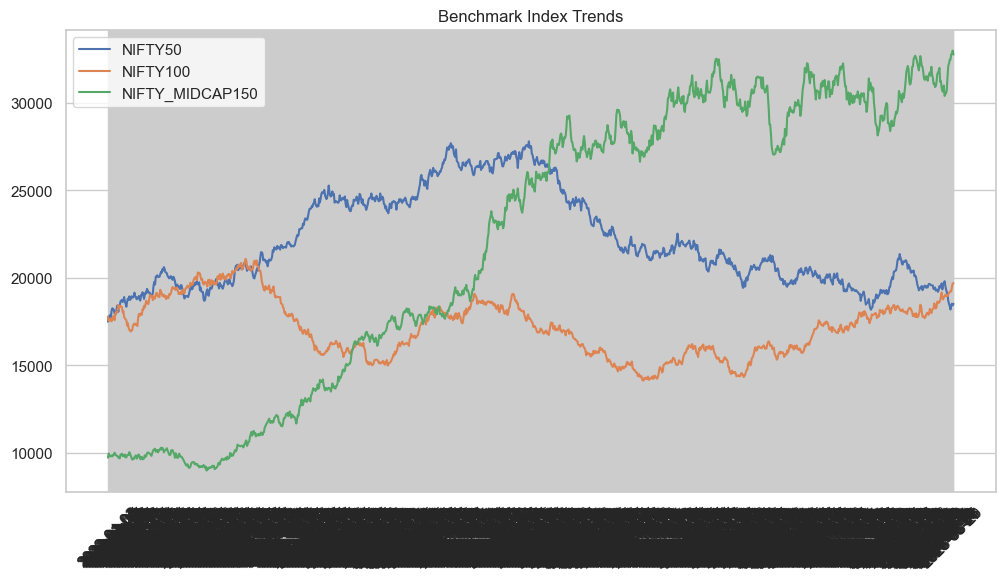

In [68]:
sample = benchmark[
    benchmark['index_name'].isin(
        benchmark['index_name'].unique()[:3]
    )
]

plt.figure(figsize=(12,6))

for idx in sample['index_name'].unique():

    temp = sample[
        sample['index_name']==idx
    ]

    plt.plot(
        temp['date'],
        temp['close_value'],
        label=idx
    )

plt.legend()

plt.xticks(rotation=45)

plt.title("Benchmark Index Trends")

plt.savefig("../charts/benchmark_trend.png")
plt.show()

### Key Findings

In [69]:
findings = """
1. Mutual fund folios increased from 13.26 Cr to 26.12 Cr between 2022 and 2025.

2. SIP inflows consistently increased, showing rising retail participation.

3. T30 cities contributed the majority of investments compared to B30 cities.

4. Banking, IT, Pharma, and Automobile dominated sector allocations.

5. Small-cap and mid-cap funds generated higher returns but carried greater risk.

6. Risk-return analysis clearly showed the tradeoff across categories.

7. Benchmark indices exhibited long-term growth.

8. Correlation analysis indicated diversification opportunities.

9. Equity folios grew faster than debt folios.

10. Investor participation increased significantly during the study period.
"""

print(findings)


1. Mutual fund folios increased from 13.26 Cr to 26.12 Cr between 2022 and 2025.

2. SIP inflows consistently increased, showing rising retail participation.

3. T30 cities contributed the majority of investments compared to B30 cities.

4. Banking, IT, Pharma, and Automobile dominated sector allocations.

5. Small-cap and mid-cap funds generated higher returns but carried greater risk.

6. Risk-return analysis clearly showed the tradeoff across categories.

7. Benchmark indices exhibited long-term growth.

8. Correlation analysis indicated diversification opportunities.

9. Equity folios grew faster than debt folios.

10. Investor participation increased significantly during the study period.



### Conclusion

In [70]:
conclusion = """
The EDA reveals strong growth in India's mutual fund industry between 2022 and 2025.

Increasing SIP inflows, rising folio counts, and strong equity performance indicate growing investor confidence.

Risk and return analyses highlight the importance of diversification and category selection for long-term wealth creation.

Overall, the mutual fund ecosystem demonstrates healthy expansion and increasing market participation.
"""

print(conclusion)


The EDA reveals strong growth in India's mutual fund industry between 2022 and 2025.

Increasing SIP inflows, rising folio counts, and strong equity performance indicate growing investor confidence.

Risk and return analyses highlight the importance of diversification and category selection for long-term wealth creation.

Overall, the mutual fund ecosystem demonstrates healthy expansion and increasing market participation.

